In [1]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\aksha\Downloads\archive
['.ipynb_checkpoints', 'data', 'Ecommerce Order Dataset', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb']


C:\Users\aksha\Downloads\archive\Ecommerce Order Dataset\train
{'orders': (89316, 7), 'items': (89316, 5), 'customers': (89316, 4), 'products': (89316, 6), 'payments': (89316, 5)}
(87422, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,delivery_time_days,delay_days,is_late,purchase_month,item_value,shipping_charges,shipment_volume,product_weight_g,product_category,seller_count,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_type,freight_to_value_ratio
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,4.140255,-13.069537,False,2017-10,223.51,84.65,1,491.0,toys,1,58125,varzea paulista,SP,259.14,credit_card,0.378730
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,13.049201,-20.047662,False,2018-06,170.80,23.79,1,440.0,watches_gifts,1,3112,armacao dos buzios,RJ,382.39,credit_card,0.139286
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,10.382164,-8.937616,False,2018-02,64.40,17.38,1,2200.0,costruction_tools_garden,1,4119,jandira,SP,249.25,credit_card,0.269876
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,9.082894,-22.163993,False,2018-08,264.50,30.72,1,1450.0,toys,1,18212,uberlandia,MG,27.79,credit_card,0.116144
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,14.110243,-12.192488,False,2017-12,779.90,30.66,1,300.0,toys,1,88868,ilhabela,SP,76.15,credit_card,0.039313


,count,mean,std,min,25%,50%,75%,max
delivery_time_days,87422.0,12.434251,9.271628,0.533414,6.732083,10.193484,15.455674,209.628611
delay_days,87422.0,-11.434642,10.041543,-146.016123,-16.359126,-12.094572,-6.556516,188.975081
item_value,87422.0,342.275791,559.754862,0.850000,59.650000,136.900000,399.200000,6735.000000
shipping_charges,87422.0,44.244947,37.656719,0.000000,20.040000,35.010000,57.150000,409.680000
product_weight_g,87422.0,2081.975144,3735.368307,0.000000,300.000000,700.000000,1800.000000,40425.000000
payment_value,87422.0,268.791023,344.826009,0.000000,84.340000,171.865000,313.550000,7274.880000
freight_to_value_ratio,87422.0,0.826341,4.051840,0.000000,0.072984,0.221800,0.607238,205.282353


Average delivery time: 12.43
Median delivery time: 10.19
Late delivery rate: 7.71 %
Average shipping charge: 44.24


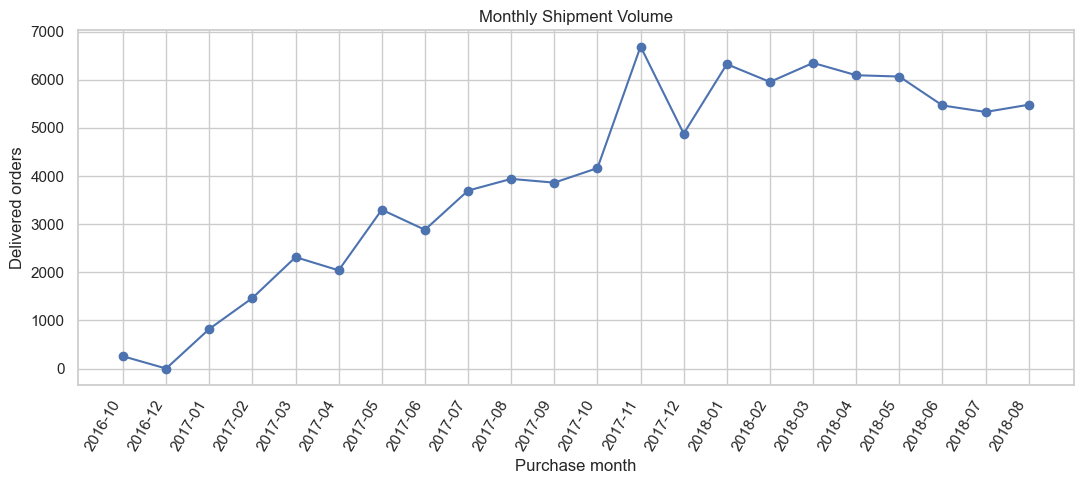

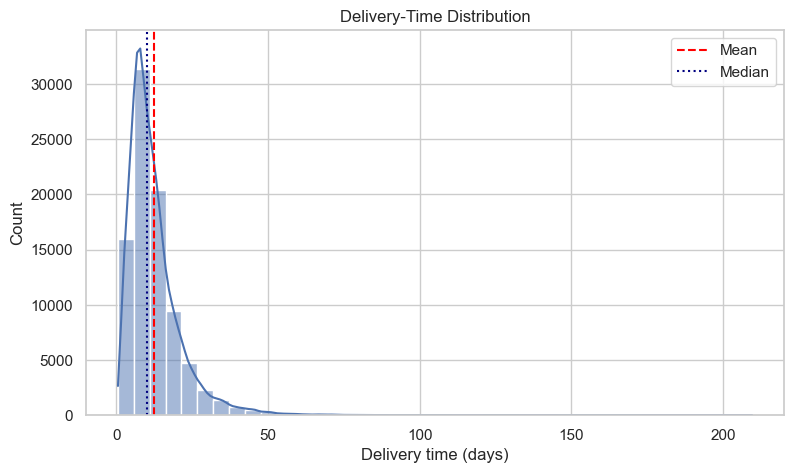

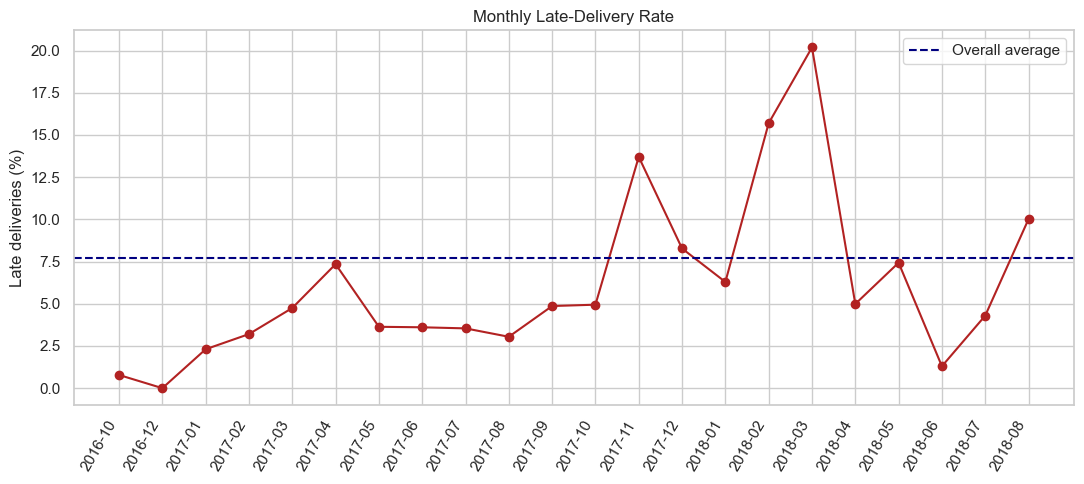

,customer_state,orders,late_rate,avg_delivery_days,avg_shipping
9,MA,603,20.729685,21.289864,44.000232
5,CE,1101,15.168029,20.704148,48.464514
4,BA,3014,13.968149,19.333120,46.631941
18,RJ,11249,12.694462,15.208551,42.598070
13,PA,799,11.639549,23.241200,47.894293
7,ES,1777,11.592572,15.567490,43.644789
15,PE,1445,10.449827,18.321266,51.786311
11,MS,631,9.984152,15.540226,45.029620
23,SC,3160,9.335443,14.968185,44.433560
8,GO,1816,7.819383,15.181051,44.702599


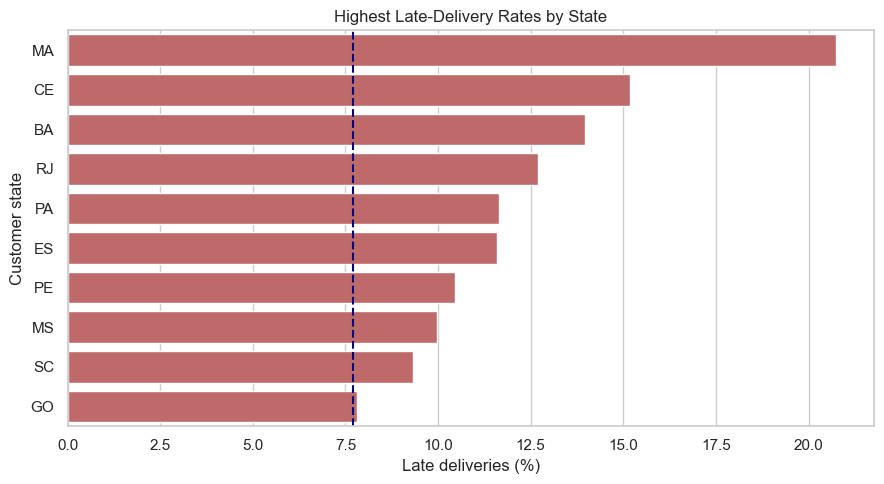

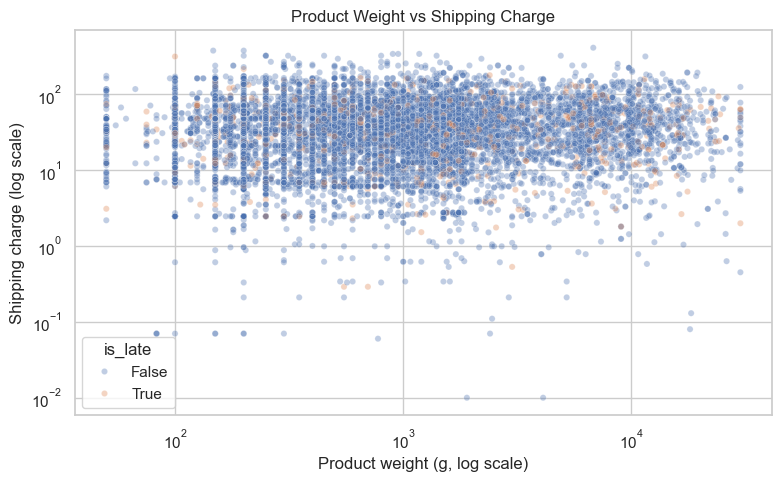

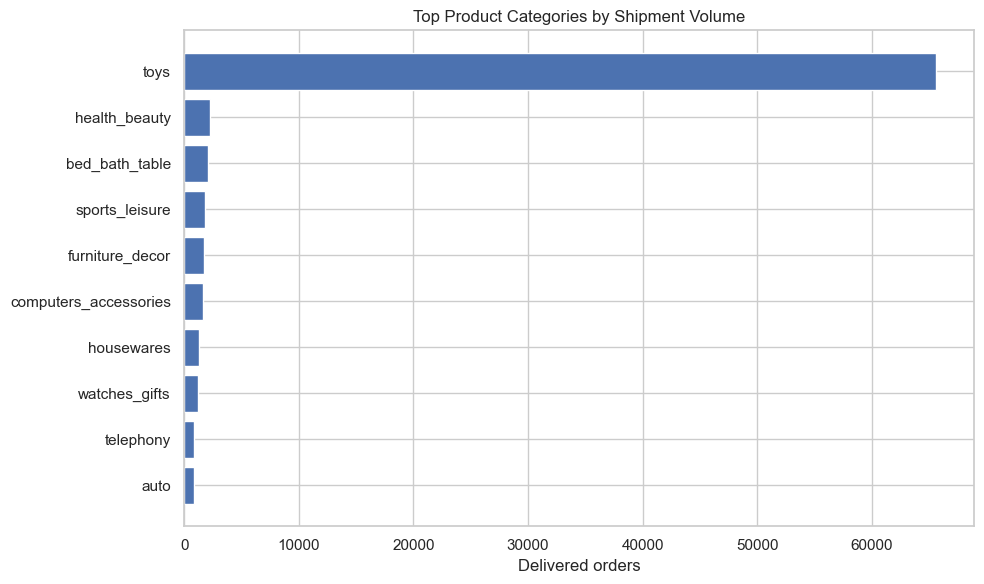

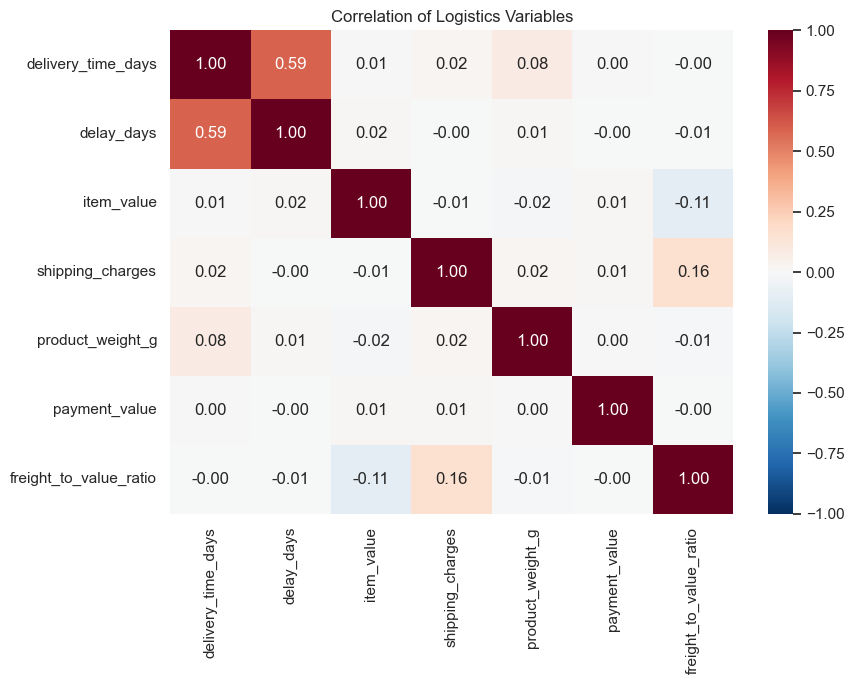

Outputs saved to C:\Users\aksha\Downloads\archive\week3_outputs


In [2]:
# Week 3 Advanced Logistics Analysis


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns",100)
sns.set_theme(style="whitegrid")


root = Path.cwd()
orders_file = next(p for p in root.rglob("df_Orders.csv") if "train" in [x.lower() for x in p.parts])
data_path = orders_file.parent
orders = pd.read_csv(data_path/"df_Orders.csv")
order_items = pd.read_csv(data_path/"df_OrderItems.csv")
customers = pd.read_csv(data_path/"df_Customers.csv")
products = pd.read_csv(data_path/"df_Products.csv")
payments = pd.read_csv(data_path/"df_Payments.csv")
print(data_path)
print({"orders":orders.shape,"items":order_items.shape,"customers":customers.shape,"products":products.shape,"payments":payments.shape})


date_cols=["order_purchase_timestamp","order_approved_at","order_delivered_timestamp","order_estimated_delivery_date"]
for col in date_cols:
    orders[col]=pd.to_datetime(orders[col],errors="coerce")
delivery=orders.loc[
    orders["order_status"].eq("delivered") & orders["order_purchase_timestamp"].notna() &
    orders["order_delivered_timestamp"].notna() & orders["order_estimated_delivery_date"].notna()
].copy()
delivery["delivery_time_days"]=(delivery["order_delivered_timestamp"]-delivery["order_purchase_timestamp"]).dt.total_seconds()/86400
delivery["delay_days"]=(delivery["order_delivered_timestamp"]-delivery["order_estimated_delivery_date"]).dt.total_seconds()/86400
delivery=delivery[delivery["delivery_time_days"]>=0].copy()
delivery["is_late"]=delivery["delay_days"]>0
delivery["purchase_month"]=delivery["order_purchase_timestamp"].dt.to_period("M").astype(str)


product_lookup=products.drop_duplicates("product_id")
item_product=order_items.merge(product_lookup,on="product_id",how="left",validate="many_to_one")
item_summary=item_product.groupby("order_id",as_index=False).agg(
    item_value=("price","sum"),shipping_charges=("shipping_charges","sum"),
    shipment_volume=("product_id","count"),product_weight_g=("product_weight_g","sum"),
    product_category=("product_category_name","first"),seller_count=("seller_id","nunique"))
payment_summary=payments.groupby("order_id",as_index=False).agg(
    payment_value=("payment_value","sum"),payment_type=("payment_type","first"))
logistics=(delivery.merge(item_summary,on="order_id",how="left",validate="one_to_one")
           .merge(customers,on="customer_id",how="left",validate="one_to_one")
           .merge(payment_summary,on="order_id",how="left",validate="one_to_one"))
logistics["freight_to_value_ratio"]=logistics["shipping_charges"]/logistics["item_value"].replace(0,np.nan)
print(logistics.shape)
display(logistics.head())


metrics=["delivery_time_days","delay_days","item_value","shipping_charges","product_weight_g","payment_value","freight_to_value_ratio"]
display(logistics[metrics].describe().T)
print("Average delivery time:",round(logistics.delivery_time_days.mean(),2))
print("Median delivery time:",round(logistics.delivery_time_days.median(),2))
print("Late delivery rate:",round(logistics.is_late.mean()*100,2),"%")
print("Average shipping charge:",round(logistics.shipping_charges.mean(),2))


monthly=logistics.groupby("purchase_month").agg(
    orders=("order_id","count"),avg_delivery_days=("delivery_time_days","mean"),
    late_rate=("is_late","mean"),shipping_cost=("shipping_charges","sum")).reset_index()
monthly["late_rate"]*=100
plt.figure(figsize=(11,5)); plt.plot(monthly.purchase_month,monthly.orders,marker="o")
plt.title("Monthly Shipment Volume"); plt.xlabel("Purchase month"); plt.ylabel("Delivered orders")
plt.xticks(rotation=60,ha="right"); plt.tight_layout(); plt.show()


plt.figure(figsize=(9,5)); sns.histplot(logistics.delivery_time_days,bins=40,kde=True)
plt.axvline(logistics.delivery_time_days.mean(),color="red",ls="--",label="Mean")
plt.axvline(logistics.delivery_time_days.median(),color="navy",ls=":",label="Median")
plt.title("Delivery-Time Distribution"); plt.xlabel("Delivery time (days)"); plt.legend(); plt.show()


plt.figure(figsize=(11,5)); plt.plot(monthly.purchase_month,monthly.late_rate,color="firebrick",marker="o")
plt.axhline(logistics.is_late.mean()*100,color="navy",ls="--",label="Overall average")
plt.title("Monthly Late-Delivery Rate"); plt.ylabel("Late deliveries (%)"); plt.xticks(rotation=60,ha="right"); plt.legend(); plt.tight_layout(); plt.show()


state=logistics.groupby("customer_state").agg(
    orders=("order_id","count"),late_rate=("is_late","mean"),
    avg_delivery_days=("delivery_time_days","mean"),avg_shipping=("shipping_charges","mean")).reset_index()
state["late_rate"]*=100
state_large=state[state.orders>=500].sort_values("late_rate",ascending=False)
display(state_large.head(10))
plt.figure(figsize=(9,5)); sns.barplot(data=state_large.head(10),x="late_rate",y="customer_state",color="indianred")
plt.axvline(logistics.is_late.mean()*100,color="navy",ls="--"); plt.title("Highest Late-Delivery Rates by State")
plt.xlabel("Late deliveries (%)"); plt.ylabel("Customer state"); plt.tight_layout(); plt.show()


sample=logistics.sample(min(12000,len(logistics)),random_state=42)
plt.figure(figsize=(9,5)); sns.scatterplot(data=sample,x="product_weight_g",y="shipping_charges",hue="is_late",alpha=.35,s=20)
plt.xscale("log"); plt.yscale("log"); plt.title("Product Weight vs Shipping Charge")
plt.xlabel("Product weight (g, log scale)"); plt.ylabel("Shipping charge (log scale)"); plt.show()


category=logistics.groupby("product_category").agg(
    orders=("order_id","count"),avg_shipping=("shipping_charges","mean"),
    avg_delivery_days=("delivery_time_days","mean"),late_rate=("is_late","mean")).reset_index()
category["late_rate"]*=100
top_categories=category.nlargest(10,"orders").sort_values("orders")
plt.figure(figsize=(10,6)); plt.barh(top_categories.product_category,top_categories.orders)
plt.title("Top Product Categories by Shipment Volume"); plt.xlabel("Delivered orders"); plt.tight_layout(); plt.show()


corr_cols=["delivery_time_days","delay_days","item_value","shipping_charges","product_weight_g","payment_value","freight_to_value_ratio"]
correlation=logistics[corr_cols].corr()
plt.figure(figsize=(9,7)); sns.heatmap(correlation,annot=True,fmt=".2f",cmap="RdBu_r",center=0,vmin=-1,vmax=1)
plt.title("Correlation of Logistics Variables"); plt.tight_layout(); plt.show()


output=Path("week3_outputs"); output.mkdir(exist_ok=True)
logistics.to_csv(output/"week3_logistics_analysis.csv",index=False)
monthly.to_csv(output/"monthly_logistics_summary.csv",index=False)
state.to_csv(output/"state_logistics_summary.csv",index=False)
category.to_csv(output/"category_logistics_summary.csv",index=False)
print("Outputs saved to",output.resolve())
